# Goal
Label the mixed dataet as:
- $s = 0$: real
- $s = 1$: synthetic

Then train an RF to predict $s$ from the features $x$:
$$
\hat{p}(x) \;=\; \widehat{P}(s=1 \mid x),
$$
i.e., the predicted probability that an observation is synthetic.

We then evaluate separability using AUC computed from ($\hat{p}(x)$) on a held-out mixed test set:
- AUC ($\approx 0.5$): RF cannot distinguish real vs synthetic (desired)
- AUC ($> 0.5$): RF can distinguish the domains (synthetic differs from real)

#### Note: 
Because the dataset is small for HIV+ ($n = 68$) and HIV- ($n = 23$), we are going to **stratify sample**:
1. Split the data into stratas (groups)
2. Then sample insid each stratum separately


Naively we might sample holdouts as:
```python
rng.choice(all_indices, size=15)
```
The main issue is that HIV+ and HIV- are expexcted to have unsimilar values across all features.

And because the real and synthetic pools can each have different HIV−/HIV+ proportions when sampled, this runs the risk of RF detecting class-composition differences rather than feature-level differences between real and synthetic.

So we instead sample **stratified** holdouts:
```python
sample 3 from HIV-
sample 12 from HIV+
combine them
```
Stratification enforces equal HIV composition across domains, so any separability detected by the RF must arise from differences in feature distributions within HIV strata rather than from HIV prevalence imbalance.
$$
H_{0} : p(x \mid s = 0, y)  = p(x \mid s = 1, y), \quad y = \text{HIV+, HIV-}
$$.

HIV status is a structured covariate that influences feature distributions.
Stratification equalizes its prevalence across domains so that domain separability reflects within-stratum feature differences rather than mixture imbalance.

### Libraries

In [1]:
import numpy as np
import pandas as pd
from IPython.display import  display, Markdown, HTML
rng = np.random.default_rng(42)
np.set_printoptions(suppress=True, precision=3)

## Helper Functions

### Helper 1: Loading Data

In [2]:
# Real data
import pyreadr
original_data = pyreadr.read_r("../../data/allSyntheticData.RData")
x_o = original_data["x"]
y_o = original_data["y"]

print(x_o.shape) # 91, 63
print((y_o == 1).sum()) # 68 HIV+, 23 HIV- 

X_real = np.asarray(x_o)
y_real = np.asarray(y_o).flatten().astype(int)

(91, 63)
y    68
dtype: int64


In [3]:
# Synthetic data merging (HIV+ and HIV- were generated separately, so we need to merge them together)
syn0 = np.load("../../data/log1p/samples/cvae_synth_seed42_y0.npz")
syn1 = np.load("../../data/log1p/samples/cvae_synth_seed42_y1.npz")

x_syn0 = syn0["X"] # 91, 63
x_syn1 = syn1["X"] # 91, 63
X_syn = np.vstack([x_syn0, x_syn1])

# We need to add the labelss HIV- = 0, HIV+ = 1
y_syn = np.concatenate([np.zeros(x_syn0.shape[0]), np.ones(x_syn1.shape[0])]).astype(int)

# __________________________________________________________
# NB visual
col_names = original_data["x"].columns
# print(col_names)
cvae_df = pd.DataFrame(X_syn, columns=col_names)
df_left1 = cvae_df.iloc[:5, :5] 
df_right1 = pd.DataFrame({
    "Label": y_syn[:5]
})
display(
    Markdown("### First 5 rows of synthetic data (HIV-)"),
    HTML(
    "<div style='display:flex; gap:40px;'>"
    f"<div>{df_left1.to_html(index=False)}</div>"
    f"<div>{df_right1.to_html(index=False)}</div>"
    "</div>"
))
df_left2 = cvae_df.iloc[-5:, :5] 
df_right2 = pd.DataFrame({
    "Label": y_syn[-5:]
})
display(
    Markdown("### Last 5 rows of synthetic data (HIV+)"),
    HTML(
    "<div style='display:flex; gap:40px;'>"
    f"<div>{df_left2.to_html(index=False)}</div>"
    f"<div>{df_right2.to_html(index=False)}</div>"
    "</div>"
))


### First 5 rows of synthetic data (HIV-)

### Last 5 rows of synthetic data (HIV+)

### Helper 2: Stratified Sampler

In [4]:
def strat_samp(neg_i, posi_i, n_neg, n_posi):
    chosen_neg = rng.choice(neg_i, size = n_neg, replace = False)
    chosen_posi = rng.choice(posi_i, size = n_posi, replace = False)
    return np.concatenate([chosen_neg, chosen_posi])

# Example
neg_i = np.where(y_real == 0)[0]
posi_i = np.where(y_real == 1)[0]
sampled_indices = strat_samp(neg_i, posi_i, n_neg=5, n_posi=5)
print("Sampled indices:", sampled_indices)

Sampled indices: [15  9 13  1 22 87 29 57 74 72]


## Random Forest
One stochastic Random Forest instance contains:
- Test holdout = $3 \text{ HIV-}$, $12 \text{ HIV+}$ one from real, and another from synthetic
- Training = $20 \text{ HIV-}$, $20 \text{ HIV+}$ one from real, and another from synthetic
- real : $0$, syn : $1$
- RF 200 trees

In [5]:
from sklearn.ensemble import RandomForestClassifier

def train_rf(X_train, s_train):
    rf = RandomForestClassifier(n_estimators = 200, random_state = 42, n_jobs=-1)
    rf.fit(X_train, s_train)
    return rf

## AUC
With our labels $s$, RF will producee a score (probability):
$$
\hat{p}(x) = \hat{P}(s= 1\mid x)
$$

Then the empirical AUC is:
$$
AUC = \frac{1}{n_{s=1}\cdot n_{s=0} } \sum_{i:s_{i}=1} \sum_{j:s_{j}=0} 1(\hat{p_{i}} > \hat{p_{j}})
$$
The probability that a randomly chosen synthetic sample receives a higher predicted score than a randomly chosen real sample.

For every synthetic–real pair, we:

1. Compare their predicted probabilities

2. Count 1 if synthetic has higher score

3. Count 0 otherwise

4. Average over all pairs

*Note: If `synthetic score == real score` count 0.5*

In [6]:
from sklearn.metrics import roc_auc_score

def get_auc(model, X_test, s_test):
    probs = model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class
    auc = roc_auc_score(s_test, probs)
    return auc

# Running one stochastic experiment

In [7]:
def one_stochastic_experiment(
    X_real, y_real_hiv,
    X_syn,  y_syn_hiv,
    holdout_neg=3, holdout_pos=12,
    train_neg=20,  train_pos=20,
):

    #strat sample
    real_neg = np.where(y_real_hiv == 0)[0]
    real_pos = np.where(y_real_hiv == 1)[0]
    syn_neg  = np.where(y_syn_hiv  == 0)[0]
    syn_pos  = np.where(y_syn_hiv  == 1)[0]

    #test/holdout: 3:12 
    test_real_idx = strat_samp(real_neg, real_pos, holdout_neg, holdout_pos)
    test_syn_idx  = strat_samp(syn_neg,  syn_pos,  holdout_neg, holdout_pos)

    # remaining indices for training 
    rem_real = np.setdiff1d(np.arange(X_real.shape[0]), test_real_idx)
    rem_syn  = np.setdiff1d(np.arange(X_syn.shape[0]),  test_syn_idx)

    rem_real_neg = rem_real[y_real_hiv[rem_real] == 0]
    rem_real_pos = rem_real[y_real_hiv[rem_real] == 1]
    rem_syn_neg  = rem_syn[y_syn_hiv[rem_syn] == 0]
    rem_syn_pos  = rem_syn[y_syn_hiv[rem_syn] == 1]


    train_real_idx = strat_samp(rem_real_neg, rem_real_pos, train_neg, train_pos)
    train_syn_idx  = strat_samp(rem_syn_neg,  rem_syn_pos,  train_neg, train_pos)


    # Real vs. Syn -classification dataset prep
    X_train = np.vstack([X_real[train_real_idx], X_syn[train_syn_idx]])
    s_train = np.concatenate([np.zeros(len(train_real_idx), dtype=int),
                              np.ones(len(train_syn_idx), dtype=int)])

    X_test  = np.vstack([X_real[test_real_idx],  X_syn[test_syn_idx]])
    s_test  = np.concatenate([np.zeros(len(test_real_idx), dtype=int),
                              np.ones(len(test_syn_idx), dtype=int)])


    rf = train_rf(X_train, s_train)

    p_syn = rf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(s_test, p_syn)


    return auc, X_train, s_train, X_test, s_test

# Okay, so that's not good.

In [8]:
score, X_train, s_train, X_test, s_test = one_stochastic_experiment(X_real, y_real, X_syn, y_syn)
display(Markdown(f"### AUC (one iteration): {score:.4f}"))
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Train real count:", (s_train == 0).sum())
print("Train syn count:", (s_train == 1).sum())

print("Test real count:", (s_test == 0).sum())
print("Test syn count:", (s_test == 1).sum())

print("Mean real (test):", X_test[s_test==0].mean())
print("Mean syn  (test):", X_test[s_test==1].mean())
print("Std real:", X_test[s_test==0].std())
print("Std syn :", X_test[s_test==1].std())

### AUC (one iteration): 0.9511

Train shape: (80, 63)
Test shape: (30, 63)
Train real count: 40
Train syn count: 40
Test real count: 15
Test syn count: 15
Mean real (test): 375.7611422347314
Mean syn  (test): 269.4066798548224
Std real: 807.4178892226229
Std syn : 500.4326075920921


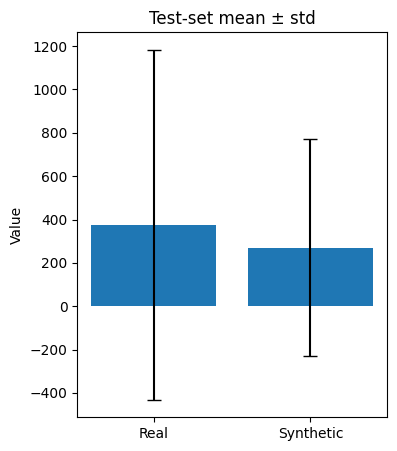

In [9]:
import numpy as np
import matplotlib.pyplot as plt

real_vals = X_test[s_test == 0].flatten()
syn_vals  = X_test[s_test == 1].flatten()

means = [real_vals.mean(), syn_vals.mean()]
stds  = [real_vals.std(),  syn_vals.std()]

labels = ["Real", "Synthetic"]

plt.figure(figsize=(4,5))

plt.bar(labels, means, yerr=stds, capsize=5)
plt.ylabel("Value")
plt.title("Test-set mean ± std")

plt.show()

# Feature-wise means

In [10]:
mean_diff = X_syn.mean(axis=0) - X_real.mean(axis=0)

df_diff = pd.DataFrame({
    "feature": col_names,
    "mean_diff": mean_diff
})

df_diff_sorted = df_diff.reindex(
    df_diff["mean_diff"].abs().sort_values(ascending=False).index
)
df_diff_sorted["mean_diff"] = df_diff["mean_diff"].round(1)

display(df_diff_sorted.head(25)) 
display(Markdown("\\+ is favour synthetic, - is favour real"))


,feature,mean_diff
26,V10_blood_IgGRBD,-919.8
25,V9_blood_IgGRBD,-620.9
58,V9Neut,-487.9
21,V6_blood_IgGRBD,-431.7
27,V11_blood_IgGRBD,-389.1
16,V10_blood_IgGspike,-287.3
22,V8_blood_IgGRBD,-281.4
23,V8a_blood_IgGRBD,-240.8
24,V8b_blood_IgGRBD,-226.7
62,V9_ACE2,-213.0


\+ is favour synthetic, - is favour real

# Added noise component to the model

In [11]:
syn0_noise = np.load("../../data/output/cvae_synth_seed42_y0_noise0.1.npz")
syn1_noise = np.load("../../data/output/cvae_synth_seed42_y1_noise0.1.npz")


x_syn0_n = syn0_noise["X"] # 91, 63
x_syn1_n = syn1_noise["X"] # 91, 63
X_syn_n = np.vstack([x_syn0_n, x_syn1_n])

# We need to add the labelss HIV- = 0, HIV+ = 1
y_syn_n = np.concatenate([np.zeros(x_syn0_n.shape[0]), np.ones(x_syn1_n.shape[0])]).astype(int)


## Baseline vs Noise AUC

In [12]:
auc_base = one_stochastic_experiment(
    X_real, y_real,
    X_syn,  y_syn,
    holdout_neg=3, holdout_pos=12,
    train_neg=20,  train_pos=20
)[0]

auc_noise = one_stochastic_experiment(
    X_real, y_real,
    X_syn_n,  y_syn_n,
    holdout_neg=3, holdout_pos=12,
    train_neg=20,  train_pos=20
)[0]

print("Baseline AUC:", auc_base)
print("Noise AUC:", auc_noise)

Baseline AUC: 0.9733333333333333
Noise AUC: 0.9222222222222223


In [13]:
def many_experiments(X_real, y_real, X_syn, y_syn, R=30, **kwargs):
    aucs = []
    for _ in range(R):
        auc, *_ = one_stochastic_experiment(X_real, y_real, X_syn, y_syn, **kwargs)
        aucs.append(auc)
    aucs = np.array(aucs, dtype=float)
    return aucs.mean(), aucs.std(), aucs

m_base, s_base, _ = many_experiments(X_real, y_real, X_syn, y_syn, R=30, holdout_neg=3, holdout_pos=12, train_neg=20, train_pos=20)
m_noise, s_noise, _ = many_experiments(X_real, y_real, X_syn_n, y_syn_n, R=30,
                                       holdout_neg=3, holdout_pos=12, train_neg=20, train_pos=20)

print(f"Baseline: {m_base:.3f} ± {s_base:.3f}")
print(f"Noise:    {m_noise:.3f} ± {s_noise:.3f}")

Baseline: 0.966 ± 0.027
Noise:    0.976 ± 0.030


In [14]:
print("RF inputs:")
print("real min/max:", X_real.min(), X_real.max())
print("syn  min/max:", X_syn.min(),  X_syn.max())
print("real mean/std:", X_real.mean(), X_real.std())
print("syn  mean/std:", X_syn.mean(),  X_syn.std())

RF inputs:
real min/max: 0.0 4453.99
syn  min/max: -0.034177855 5085.9385
real mean/std: 381.0895862018761 783.6086805358219
syn  mean/std: 291.06677 541.01514


# The rest below really should've been placed in the other ablation file

# Feature real vs Feature synth

In [15]:
from sklearn.metrics import roc_auc_score

aucs = []
for j in range(X_real.shape[1]):
    x = np.concatenate([X_real[:, j], X_syn[:, j]])
    s = np.concatenate([np.zeros(X_real.shape[0]), np.ones(X_syn.shape[0])])
    aucs.append(roc_auc_score(s, x))

aucs = np.array(aucs)
top = np.argsort(-np.abs(aucs - 0.5))[:10]
print("Top separable features:")
for j in top:
    print(f"{j} ({col_names[j]}): AUC = {aucs[j]:.4f}")

Top separable features:
17 (V11_blood_IgGspike): AUC = 0.3334
28 (V4_Saliva_IgGspike): AUC = 0.3408
16 (V10_blood_IgGspike): AUC = 0.3587
56 (RATIO_CD4CD8): AUC = 0.6355
18 (V1_blood_IgGRBD): AUC = 0.6139
52 (V9Dual): AUC = 0.3870
50 (V8_IL2): AUC = 0.3909
49 (V9_IFNg): AUC = 0.3918
29 (V4_Saliva_IgGRBD): AUC = 0.3923
51 (V9_IL2): AUC = 0.3939


# Flatten data
One long list of data:
$$
\{X_{ij} \}_{i,j} \to \{X_{11}, X_{12},...,X_{np}\}
$$

We are comparing the distribution of the two datasets to test:
$$
P(X_{\text{syn}} > X_{\text{real}})
$$
where $X$ is just any extry from anywhere

In [16]:
import numpy as np
from sklearn.metrics import roc_auc_score

real_flat = X_real.flatten()
syn_flat  = X_syn.flatten()

n = min(len(real_flat), len(syn_flat))
rng = np.random.default_rng(0)

real_s = rng.choice(real_flat, size=n, replace=False)
syn_s  = rng.choice(syn_flat,  size=n, replace=False)

x = np.concatenate([real_s, syn_s])
y = np.concatenate([np.zeros(n), np.ones(n)])

auc = roc_auc_score(y, x)
sep = max(auc, 1-auc)

print("Flattened AUC:", auc)
print("Flattened separability (max(auc,1-auc)):", sep)

Flattened AUC: 0.4988810303155822
Flattened separability (max(auc,1-auc)): 0.5011189696844178


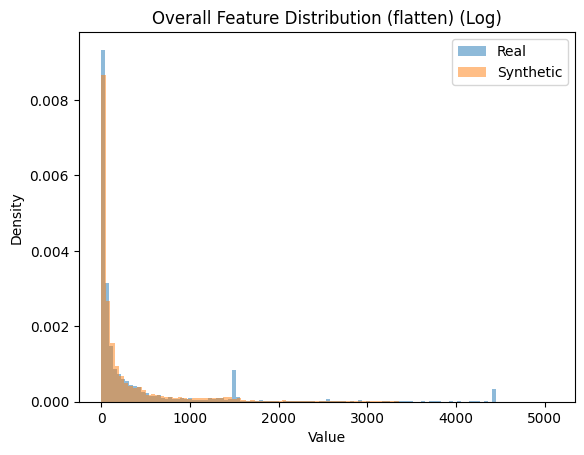

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Flatten everything into one vector
real_flat = X_real.flatten()
syn_flat  = X_syn.flatten()

plt.figure()
plt.hist(real_flat, bins=100, density=True, alpha=0.5, label="Real")
plt.hist(syn_flat,  bins=100, density=True, alpha=0.5, label="Synthetic")

plt.legend()
plt.title("Overall Feature Distribution (flatten) (Log)")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

# Per feature AUC

Feature V11_blood_IgGspike | AUC = 0.3334 | Sep = 0.6666


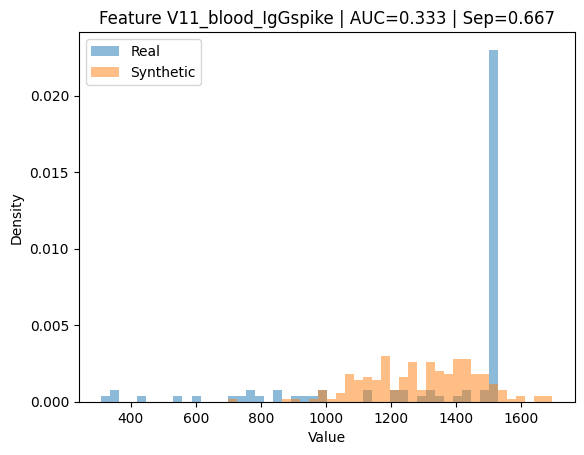

Feature V4_Saliva_IgGspike | AUC = 0.3408 | Sep = 0.6592


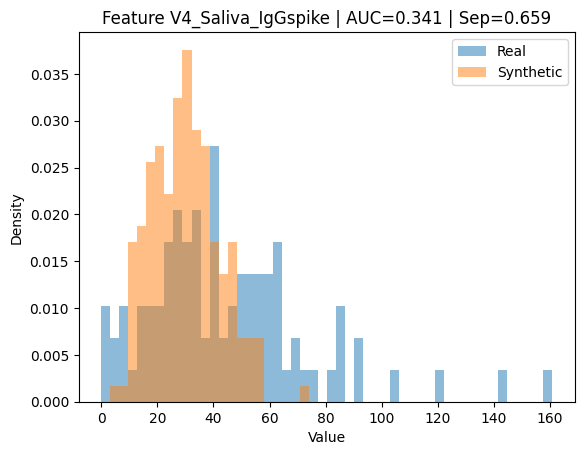

Feature V10_blood_IgGspike | AUC = 0.3587 | Sep = 0.6413


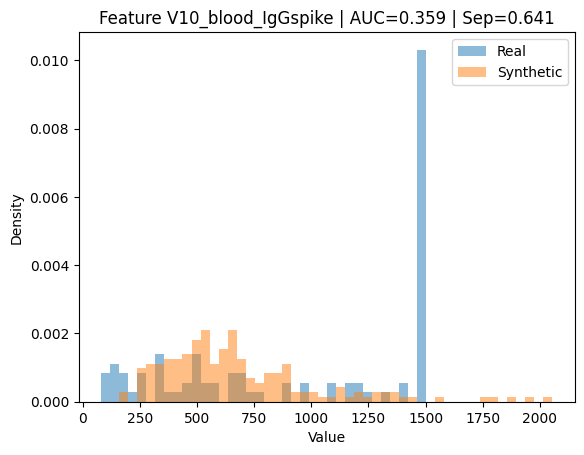

Feature RATIO_CD4CD8 | AUC = 0.6355 | Sep = 0.6355


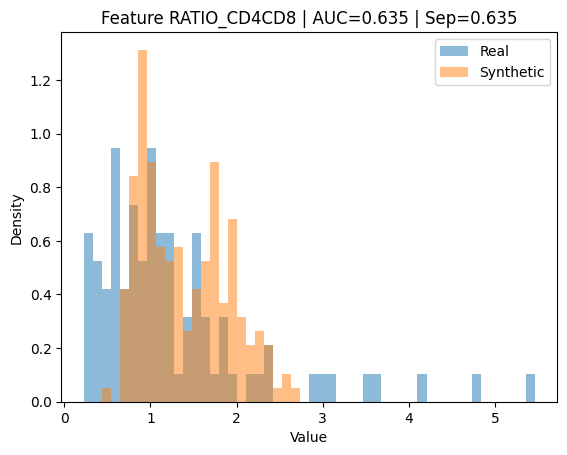

Feature V1_blood_IgGRBD | AUC = 0.6139 | Sep = 0.6139


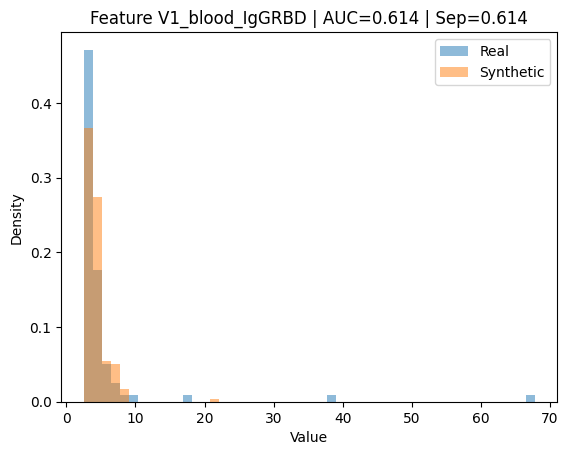

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

def per_feature_auc(X_real, X_syn):
    n_features = X_real.shape[1]
    results = []

    for j in range(n_features):
        x = np.concatenate([X_real[:, j], X_syn[:, j]])
        y = np.concatenate([
            np.zeros(X_real.shape[0]),
            np.ones(X_syn.shape[0])
        ])

        auc = roc_auc_score(y, x)
        sep = max(auc, 1 - auc)

        results.append((j, auc, sep))

    return results


results = per_feature_auc(X_real, X_syn)
results_sorted = sorted(results, key=lambda x: x[2], reverse=True)
col_names = original_data["x"].columns
# Plot top 5 most separable features
for j, auc, sep in results_sorted[:5]:
    name = col_names[j]
    print(f"Feature {name} | AUC = {auc:.4f} | Sep = {sep:.4f}")

    combined = np.concatenate([X_real[:, j], X_syn[:, j]])
    bins = np.histogram_bin_edges(combined, bins=50)

    plt.figure()
    plt.hist(X_real[:, j], bins=bins, density=True, alpha=0.5, label="Real")
    plt.hist(X_syn[:, j],  bins=bins, density=True, alpha=0.5, label="Synthetic")
    plt.title(f"Feature {name} | AUC={auc:.3f} | Sep={sep:.3f}")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

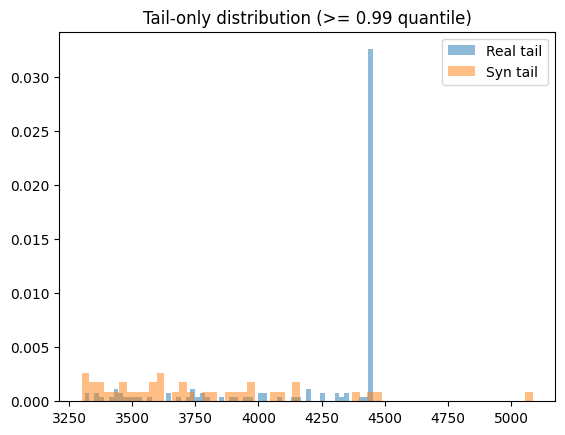

In [19]:
import numpy as np
import matplotlib.pyplot as plt

real_flat = X_real.flatten()
syn_flat  = X_syn.flatten()

q = 0.99
thr = np.quantile(np.concatenate([real_flat, syn_flat]), q)

plt.figure()
plt.hist(real_flat[real_flat >= thr], bins=60, density=True, alpha=0.5, label="Real tail")
plt.hist(syn_flat[syn_flat >= thr],  bins=60, density=True, alpha=0.5, label="Syn tail")
plt.title(f"Tail-only distribution (>= {q:.2f} quantile)")
plt.legend()
plt.show()